# EDA — Fresh vs Rotten Classification
**Kelompok 9 | COMP6577001 Machine Learning | BINUS University**

Dataset: Fruits & Vegetables (Apple, Banana, Orange, Carrot, Cucumber, Potato, Tomato)  
Task: Binary classification — Fresh (0) vs Rotten (1)

## 1. Setup

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
import random
import warnings
warnings.filterwarnings('ignore')

random.seed(42)
np.random.seed(42)

DATA_DIR = Path('../data/raw/Dataset/archive/Fruits_Vegetables_Dataset(12000)')
FIGURES_DIR = Path('../figures')
FIGURES_DIR.mkdir(exist_ok=True)

# Items yang dipakai (skip Bellpepper, Strawberry, Mango)
SELECTED_ITEMS = ['Apple', 'Banana', 'Orange', 'Carrot', 'Cucumber', 'Potato', 'Tomato']

print(f'DATA_DIR exists: {DATA_DIR.exists()}')
print(f'FIGURES_DIR: {FIGURES_DIR.resolve()}')

DATA_DIR exists: True
FIGURES_DIR: C:\Users\Rafifdiya\Desktop\Semester 4\Machine Learning\Project Machine Learning\Model\figures


## 2. Load Dataset Paths

In [2]:
def load_dataset_paths(data_dir, selected_items):
    records = []
    for category in ['Fruits', 'Vegetables']:
        cat_dir = data_dir / category
        for class_folder in sorted(cat_dir.iterdir()):
            if not class_folder.is_dir():
                continue
            name = class_folder.name  # e.g. FreshApple
            # Parse label dan item
            if name.startswith('Fresh'):
                freshness = 'Fresh'
                item = name[5:]  # remove 'Fresh'
            elif name.startswith('Rotten'):
                freshness = 'Rotten'
                item = name[6:]  # remove 'Rotten'
            else:
                continue
            if item not in selected_items:
                continue
            for img_path in class_folder.iterdir():
                if img_path.suffix.lower() in ['.jpg', '.jpeg', '.png']:
                    records.append({
                        'path': str(img_path),
                        'class_name': name,
                        'item': item,
                        'freshness': freshness,
                        'label': 0 if freshness == 'Fresh' else 1,
                        'category': category
                    })
    return pd.DataFrame(records)

df = load_dataset_paths(DATA_DIR, SELECTED_ITEMS)
print(f'Total images: {len(df)}')
print(f'Classes: {sorted(df["class_name"].unique())}')
df.head()

Total images: 8387
Classes: ['FreshApple', 'FreshBanana', 'FreshCarrot', 'FreshCucumber', 'FreshOrange', 'FreshPotato', 'FreshTomato', 'RottenApple', 'RottenBanana', 'RottenCarrot', 'RottenCucumber', 'RottenOrange', 'RottenPotato', 'RottenTomato']


,path,class_name,item,freshness,label,category
0,..\data\raw\Dataset\archive\Fruits_Vegetables_...,FreshApple,Apple,Fresh,0,Fruits
1,..\data\raw\Dataset\archive\Fruits_Vegetables_...,FreshApple,Apple,Fresh,0,Fruits
2,..\data\raw\Dataset\archive\Fruits_Vegetables_...,FreshApple,Apple,Fresh,0,Fruits
3,..\data\raw\Dataset\archive\Fruits_Vegetables_...,FreshApple,Apple,Fresh,0,Fruits
4,..\data\raw\Dataset\archive\Fruits_Vegetables_...,FreshApple,Apple,Fresh,0,Fruits


## 3. Distribusi Kelas

In [3]:
class_counts = df.groupby(['item', 'freshness']).size().unstack(fill_value=0)
print('=== Jumlah gambar per item per label ===')
print(class_counts)
print(f'\nTotal Fresh  : {df[df["label"]==0].shape[0]}')
print(f'Total Rotten : {df[df["label"]==1].shape[0]}')
print(f'Total keseluruhan: {len(df)}')

=== Jumlah gambar per item per label ===
freshness  Fresh  Rotten
item                    
Apple        612     583
Banana       623     573
Carrot       619     579
Cucumber     608     593
Orange       609     591
Potato       614     584
Tomato       604     595

Total Fresh  : 4289
Total Rotten : 4098
Total keseluruhan: 8387


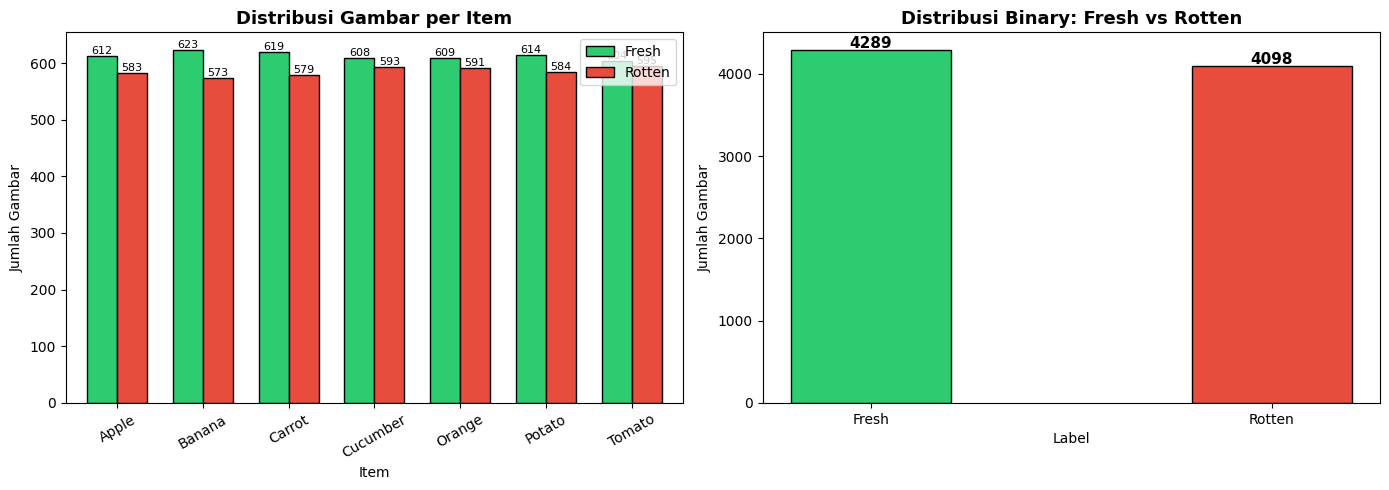

Saved: eda_class_dist.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Per item
class_counts.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'], edgecolor='black', width=0.7)
axes[0].set_title('Distribusi Gambar per Item', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Item')
axes[0].set_ylabel('Jumlah Gambar')
axes[0].legend(['Fresh', 'Rotten'])
axes[0].tick_params(axis='x', rotation=30)
for p in axes[0].patches:
    axes[0].annotate(str(int(p.get_height())),
                     (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontsize=8)

# Plot 2: Binary Fresh vs Rotten
binary_counts = df['freshness'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[1].bar(binary_counts.index, binary_counts.values, color=colors, edgecolor='black', width=0.4)
axes[1].set_title('Distribusi Binary: Fresh vs Rotten', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Jumlah Gambar')
for i, (label, count) in enumerate(binary_counts.items()):
    axes[1].text(i, count + 20, str(count), ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_class_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_class_dist.png')

## 4. Sample Gambar per Kelas

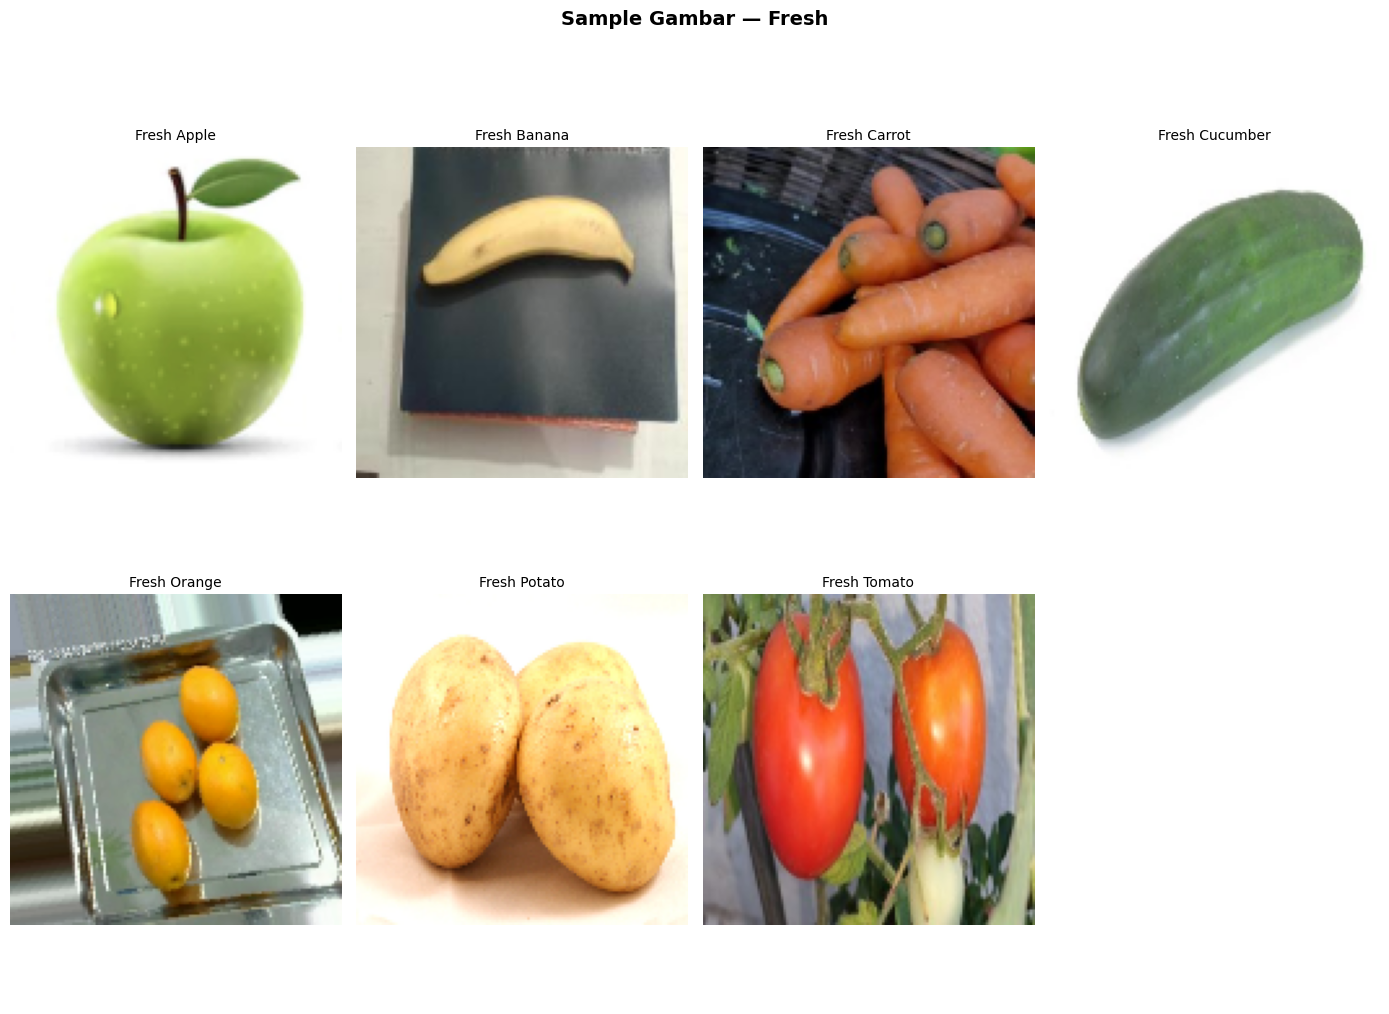

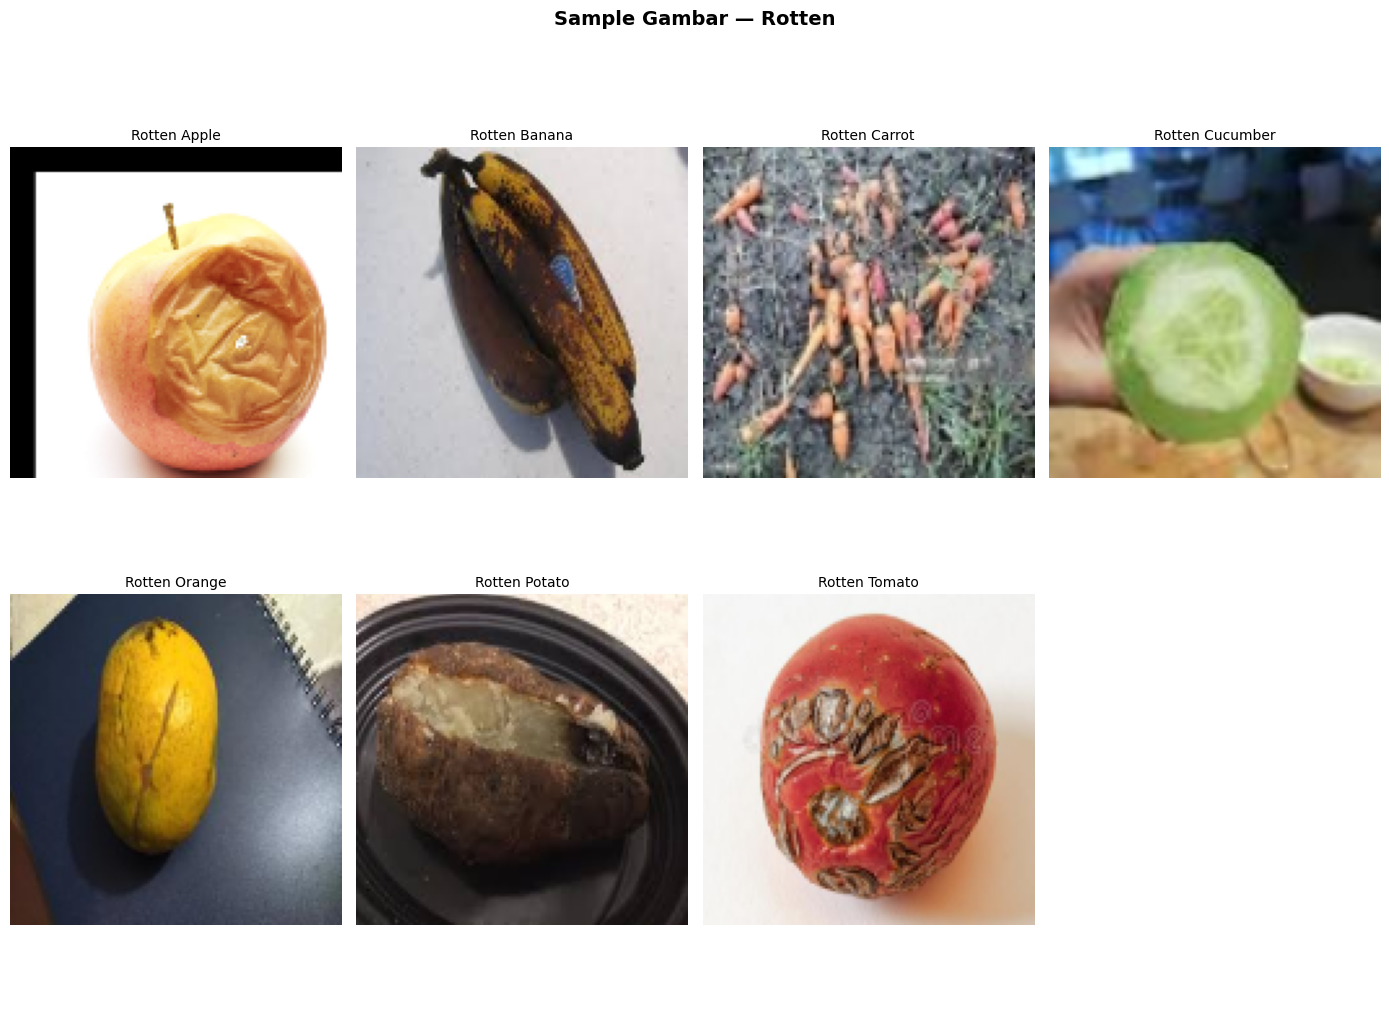

Saved: eda_sample_fresh.png, eda_sample_rotten.png


In [5]:
def show_sample_grid(df, freshness_filter, n_items=7, n_cols=4, figsize=(14, 10)):
    subset = df[df['freshness'] == freshness_filter]
    items = sorted(subset['item'].unique())
    n_rows = (len(items) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten()
    for i, item in enumerate(items):
        item_df = subset[subset['item'] == item]
        img_path = item_df.sample(1)['path'].values[0]
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (128, 128))
        axes[i].imshow(img)
        axes[i].set_title(f'{freshness_filter} {item}', fontsize=10)
        axes[i].axis('off')
    for j in range(len(items), len(axes)):
        axes[j].axis('off')
    plt.suptitle(f'Sample Gambar — {freshness_filter}', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    return fig

fig_fresh = show_sample_grid(df, 'Fresh')
fig_fresh.savefig(FIGURES_DIR / 'eda_sample_fresh.png', dpi=150, bbox_inches='tight')
plt.show()

fig_rotten = show_sample_grid(df, 'Rotten')
fig_rotten.savefig(FIGURES_DIR / 'eda_sample_rotten.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_sample_fresh.png, eda_sample_rotten.png')

## 5. Analisis Ukuran Gambar

In [6]:
sample_df = df.sample(min(500, len(df)), random_state=42)
heights, widths = [], []

for path in sample_df['path']:
    img = cv2.imread(path)
    if img is not None:
        h, w = img.shape[:2]
        heights.append(h)
        widths.append(w)

print(f'Height — min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.1f}')
print(f'Width  — min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.1f}')
print(f'\nKesimpulan: resize ke 64x64 saat preprocessing')

Height — min: 100, max: 4032, mean: 346.4
Width  — min: 100, max: 4032, mean: 402.6

Kesimpulan: resize ke 64x64 saat preprocessing


## 6. Analisis Warna HSV (Fresh vs Rotten)

In [7]:
def compute_mean_hsv(df, n_sample=200):
    results = []
    for freshness in ['Fresh', 'Rotten']:
        subset = df[df['freshness'] == freshness].sample(min(n_sample, len(df)), random_state=42)
        h_vals, s_vals, v_vals = [], [], []
        for path in subset['path']:
            img = cv2.imread(path)
            if img is None:
                continue
            img = cv2.resize(img, (64, 64))
            hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
            h_vals.append(hsv[:,:,0].mean())
            s_vals.append(hsv[:,:,1].mean())
            v_vals.append(hsv[:,:,2].mean())
        results.append({
            'freshness': freshness,
            'mean_H': np.mean(h_vals),
            'mean_S': np.mean(s_vals),
            'mean_V': np.mean(v_vals)
        })
    return pd.DataFrame(results)

hsv_df = compute_mean_hsv(df)
print('=== Mean HSV per Label ===')
print(hsv_df.to_string(index=False))

=== Mean HSV per Label ===
freshness    mean_H    mean_S     mean_V
    Fresh 43.543862 92.967787 152.971656
   Rotten 33.930610 73.002601 175.515734


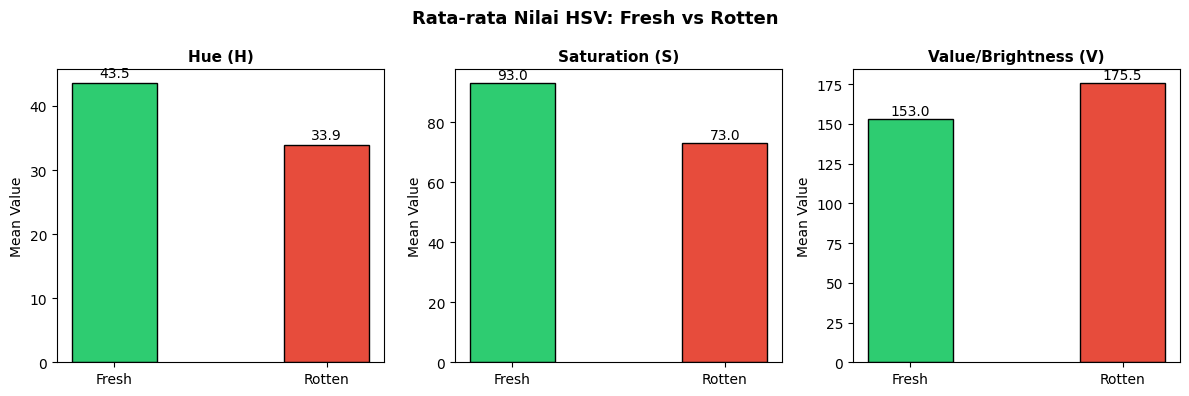

Saved: eda_hsv_analysis.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
channels = ['mean_H', 'mean_S', 'mean_V']
labels_ch = ['Hue (H)', 'Saturation (S)', 'Value/Brightness (V)']
colors_map = {'Fresh': '#2ecc71', 'Rotten': '#e74c3c'}

for ax, ch, label in zip(axes, channels, labels_ch):
    bars = ax.bar(hsv_df['freshness'], hsv_df[ch],
                  color=[colors_map[f] for f in hsv_df['freshness']],
                  edgecolor='black', width=0.4)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_ylabel('Mean Value')
    for bar, val in zip(bars, hsv_df[ch]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}', ha='center', va='bottom', fontsize=10)

plt.suptitle('Rata-rata Nilai HSV: Fresh vs Rotten', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_hsv_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_hsv_analysis.png')

## 7. Distribusi Warna HSV per Channel (Histogram)

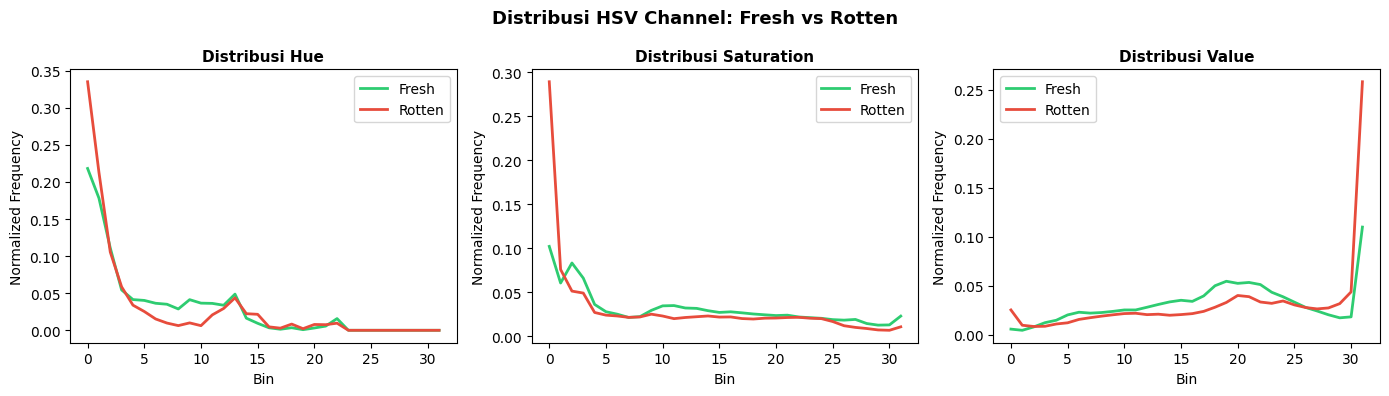

Saved: eda_hsv_histogram.png


In [9]:
def collect_hsv_histograms(df, n_sample=150):
    hist_data = {'Fresh': {0: [], 1: [], 2: []}, 'Rotten': {0: [], 1: [], 2: []}}
    for freshness in ['Fresh', 'Rotten']:
        subset = df[df['freshness'] == freshness].sample(min(n_sample, len(df)), random_state=42)
        for path in subset['path']:
            img = cv2.imread(path)
            if img is None:
                continue
            img = cv2.resize(img, (64, 64))
            hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
            for ch in range(3):
                hist = cv2.calcHist([hsv], [ch], None, [32], [0, 256])
                hist_data[freshness][ch].append(hist.flatten())
    return hist_data

hist_data = collect_hsv_histograms(df)
ch_names = ['Hue', 'Saturation', 'Value']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ch_idx, (ax, ch_name) in enumerate(zip(axes, ch_names)):
    for freshness, color in [('Fresh', '#2ecc71'), ('Rotten', '#e74c3c')]:
        mean_hist = np.mean(hist_data[freshness][ch_idx], axis=0)
        mean_hist = mean_hist / mean_hist.sum()  # normalize
        ax.plot(mean_hist, color=color, label=freshness, linewidth=2)
    ax.set_title(f'Distribusi {ch_name}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Bin')
    ax.set_ylabel('Normalized Frequency')
    ax.legend()

plt.suptitle('Distribusi HSV Channel: Fresh vs Rotten', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_hsv_histogram.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_hsv_histogram.png')

## 8. Summary EDA

In [10]:
print('=' * 50)
print('SUMMARY EDA')
print('=' * 50)
print(f'Total dataset    : {len(df)} gambar')
print(f'Fresh (label=0)  : {len(df[df["label"]==0])} gambar')
print(f'Rotten (label=1) : {len(df[df["label"]==1])} gambar')
print(f'Class balance    : {len(df[df["label"]==0])/len(df)*100:.1f}% fresh / {len(df[df["label"]==1])/len(df)*100:.1f}% rotten')
print(f'Item types       : {sorted(df["item"].unique())}')
print(f'Image format     : jpg/png')
print(f'Resize target    : 64x64 px')
print()
print('Figures saved:')
for f in sorted(FIGURES_DIR.glob('eda_*.png')):
    print(f'  {f.name}')
print()
print('Kesimpulan:')
print('- Dataset balanced → tidak perlu oversampling')
print('- Warna HSV berbeda antara fresh dan rotten → color histogram berguna sebagai fitur')
print('- Tekstur berbeda (rotten lebih soft/wrinkled) → HOG berguna sebagai fitur')
print('- Lanjut Fase 3: Feature Extraction (HOG + Color Histogram)')

SUMMARY EDA
Total dataset    : 8387 gambar
Fresh (label=0)  : 4289 gambar
Rotten (label=1) : 4098 gambar
Class balance    : 51.1% fresh / 48.9% rotten
Item types       : ['Apple', 'Banana', 'Carrot', 'Cucumber', 'Orange', 'Potato', 'Tomato']
Image format     : jpg/png
Resize target    : 64x64 px

Figures saved:
  eda_class_dist.png
  eda_hsv_analysis.png
  eda_hsv_histogram.png
  eda_sample_fresh.png
  eda_sample_rotten.png

Kesimpulan:
- Dataset balanced → tidak perlu oversampling
- Warna HSV berbeda antara fresh dan rotten → color histogram berguna sebagai fitur
- Tekstur berbeda (rotten lebih soft/wrinkled) → HOG berguna sebagai fitur
- Lanjut Fase 3: Feature Extraction (HOG + Color Histogram)
